In [ ]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

# Check if TensorFlow was built with CUDA
print("Built with CUDA:", tf.test.is_built_with_cuda())

# List available GPUs
gpus = tf.config.list_physical_devices("GPU")
print("GPUs available:", gpus)


TensorFlow version: 2.19.0
Built with CUDA: True
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# Stable Diffusion (PyTorch) – End-to-End Pipeline

This notebook:
- Uses **PyTorch only**
- Loads **Stable Diffusion v1.5**
- Generates images from text prompts
- Evaluates outputs using practical diffusion metrics
- Saves the **entire pipeline + weights**
- Allows reuse of the saved model in a **VS Code frontend (`main.py`)**

Frameworks:
- diffusers
- transformers
- torch
- safetensors


In [ ]:
!pip install -q diffusers transformers accelerate torch torchvision safetensors ftfy pillow


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.2 MB/s eta 0:00:00


## Import Libraries and Configure Device

We detect the best available device:
- CUDA (GPU)
- Apple MPS (Mac)
- CPU fallback


In [ ]:
import torch
from diffusers import StableDiffusionPipeline, EulerAncestralDiscreteScheduler
from PIL import Image
import numpy as np
import os


device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)

print("Using device:", device)


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Using device: cuda


## Load Stable Diffusion v1.5 (PyTorch)

- Loads pretrained weights from Hugging Face
- Uses Euler Ancestral scheduler for better quality
- Enables memory optimizations


In [ ]:
model_id = "runwayml/stable-diffusion-v1-5"

pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    dtype=torch.float16 if device == "cuda" else torch.float32,
    safety_checker=None,   # disable NSFW checker (optional)
)

pipe.scheduler = EulerAncestralDiscreteScheduler.from_config(
    pipe.scheduler.config
)

pipe = pipe.to(device)
pipe.enable_attention_slicing()

print("Pipeline loaded successfully")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/806 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/617 [00:00<?, ?B/s]

...

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

Keyword arguments {'dtype': torch.float16} are not expected by StableDiffusionPipeline and will be ignored.


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


Pipeline loaded successfully


## Text Prompt Definition

- `prompt` describes what we want
- `negative_prompt` tells the model what to avoid


In [ ]:
prompt = "ultra-detailed portrait of a red fox wearing a tiny scarf, cinematic lighting, 35mm"
negative_prompt = "blurry, lowres, jpeg artifacts, extra fingers, text, watermark"


## Prompt Enhancement (User → Professional Prompt)

Users usually give **short, vague prompts**.
Diffusion models perform best with:
- Subject clarity
- Style descriptors
- Camera & lighting
- Quality boosters

This cell:
- Takes a raw user prompt
- Enhances it into a **high-quality, professional diffusion prompt**
- Keeps it deterministic and controllable


In [ ]:
def enhance_prompt(
    user_prompt: str,
    style: str = "photorealistic",
    mood: str = "cinematic",
    camera: str = "35mm lens, shallow depth of field",
    lighting: str = "soft cinematic lighting, global illumination",
    quality: str = "ultra-detailed, 8k, high sharpness, professional color grading"
):
    """
    Enhances a short user prompt into a professional Stable Diffusion prompt.
    """

    enhanced_prompt = f"""
    {user_prompt},
    {style},
    {mood},
    {lighting},
    {camera},
    {quality},
    highly detailed textures,
    realistic anatomy,
    award-winning photography,
    masterpiece
    """

    # Clean formatting
    enhanced_prompt = " ".join(enhanced_prompt.split())
    return enhanced_prompt



## Example: Enhance User Prompt



In [ ]:
# Raw prompt from user (UI / frontend / input box)
user_prompt = "a red fox wearing a red scarf"

# Enhance it
enhanced_prompt = enhance_prompt(
    user_prompt,
    style="hyper-realistic animal portrait",
    mood="cinematic fantasy",
    camera="85mm DSLR lens, f1.8",
    lighting="dramatic rim lighting, soft shadows"
)

negative_prompt = (
    "blurry, lowres, jpeg artifacts, extra limbs, "
    "bad anatomy, text, watermark, logo"
)

print("USER PROMPT:\n", user_prompt)
print("\nENHANCED PROMPT:\n", enhanced_prompt)


USER PROMPT:
 a red fox wearing a red scarf

ENHANCED PROMPT:
 a red fox wearing a red scarf, hyper-realistic animal portrait, cinematic fantasy, dramatic rim lighting, soft shadows, 85mm DSLR lens, f1.8, ultra-detailed, 8k, high sharpness, professional color grading, highly detailed textures, realistic anatomy, award-winning photography, masterpiece


## Image Generation

Important parameters:
- `num_inference_steps`: image quality vs speed
- `guidance_scale`: prompt adherence
- `seed`: reproducibility


  0%|          | 0/30 [00:00<?, ?it/s]

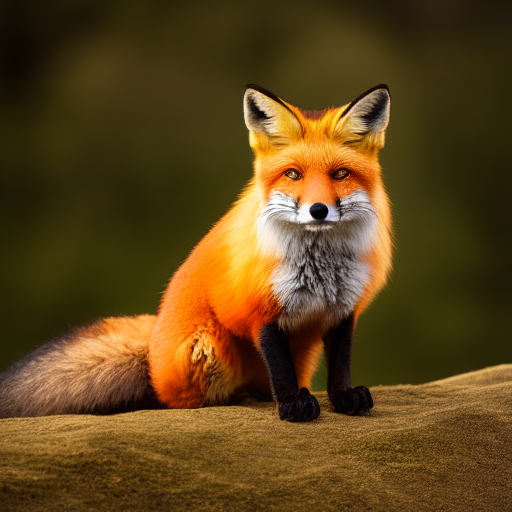

In [ ]:
generator = torch.Generator(device=device).manual_seed(42)

image = pipe(
    prompt=enhanced_prompt,
    negative_prompt=negative_prompt,
    num_inference_steps=30,
    guidance_scale=7.5,
    height=512,
    width=512,
    generator=generator
).images[0]

image.save("generated_image_enhanced.png")
image


## Evaluation Metrics for Diffusion Models

Diffusion models don't use accuracy.
Common evaluation approaches:
1. **CLIP similarity score** (text–image alignment)
2. **Inference latency**
3. **Determinism (seed reproducibility)**

Below we compute CLIP similarity using OpenAI CLIP.


In [ ]:
from transformers import CLIPProcessor, CLIPModel

clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

inputs = clip_processor(
    text=[prompt],
    images=image,
    return_tensors="pt",
    padding=True
).to(device)

with torch.no_grad():
    outputs = clip_model(**inputs)
    clip_score = outputs.logits_per_image.item()

print("CLIP similarity score:", clip_score)


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

CLIP similarity score: 32.23133087158203


## Save Model and Weights (For VS Code / Frontend)

This saves:
- UNet
- VAE
- Text Encoder
- Scheduler
- Tokenizer

You can zip and download this folder.


In [ ]:
SAVE_DIR = "/content/stable_diffusion_saved"

pipe.save_pretrained(SAVE_DIR)
print(f"Model saved to: {SAVE_DIR}")


Model saved to: stable_diffusion_saved


In [ ]:
import os
print(os.listdir("/content"))


['.config', 'generated_image_enhanced.png', 'stable_diffusion_saved', 'sample_data']


In [ ]:
!zip -r stable_diffusion_saved.zip stable_diffusion_saved


  adding: stable_diffusion_saved/ (stored 0%)
  adding: stable_diffusion_saved/vae/ (stored 0%)
  adding: stable_diffusion_saved/vae/config.json (deflated 55%)
  adding: stable_diffusion_saved/vae/diffusion_pytorch_model.safetensors (deflated 7%)
  adding: stable_diffusion_saved/feature_extractor/ (stored 0%)
  adding: stable_diffusion_saved/feature_extractor/preprocessor_config.json (deflated 48%)
  adding: stable_diffusion_saved/model_index.json (deflated 55%)
  adding: stable_diffusion_saved/tokenizer/ (stored 0%)
  adding: stable_diffusion_saved/tokenizer/special_tokens_map.json (deflated 73%)
  adding: stable_diffusion_saved/tokenizer/tokenizer_config.json (deflated 63%)
  adding: stable_diffusion_saved/tokenizer/merges.txt (deflated 60%)
  adding: stable_diffusion_saved/tokenizer/vocab.json (deflated 71%)
  adding: stable_diffusion_saved/text_encoder/ (stored 0%)
  adding: stable_diffusion_saved/text_encoder/config.json (deflated 46%)
  adding: stable_diffusion_saved/text_encoder

In [ ]:

!mv /content/stable_diffusion_saved.zip /content/drive/MyDrive/
